# IPL Win Probability Predictor


This project builds a machine learning model to estimate the probability of the chasing team winning an IPL match based on the current match state.

In [1]:
import pandas as pd
import numpy as np

matches = pd.read_csv("Downloads/archive/matches.csv")
deliveries = pd.read_csv("Downloads/archive/deliveries.csv")

print(matches.shape)
print(deliveries.shape)

matches.head()

(1095, 20)
(260920, 17)


,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [2]:
deliveries.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


## Data Preprocessing

In [3]:
total_score_df = deliveries.groupby(['match_id','inning']).sum()['total_runs'].reset_index()

total_score_df = total_score_df[total_score_df['inning'] == 1]

total_score_df['target'] = total_score_df['total_runs'] + 1

total_score_df = total_score_df[['match_id','target']]

total_score_df.head()

,match_id,target
0,335982,223
2,335983,241
4,335984,130
6,335985,166
8,335986,111


In [4]:
deliveries = deliveries.merge(total_score_df, on='match_id')

deliveries.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder,target
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN,223
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN,223
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN,223
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN,223
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN,223


In [5]:
deliveries = deliveries[deliveries['inning'] == 2]

In [6]:
deliveries.shape

(125741, 18)

## Feature Engineering

In [7]:
deliveries['runs_left'] = deliveries['target'] - deliveries.groupby('match_id')['total_runs'].cumsum()

In [8]:
deliveries['balls_left'] = 120 - (deliveries['over']*6 + deliveries['ball'])

In [9]:
deliveries['wickets'] = deliveries.groupby('match_id')['is_wicket'].cumsum()

deliveries['wickets_left'] = 10 - deliveries['wickets']

In [10]:
deliveries['current_run_rate'] = deliveries.groupby('match_id')['total_runs'].cumsum() / (deliveries['over'] + deliveries['ball']/6)

In [11]:
deliveries['required_run_rate'] = (deliveries['runs_left'] * 6) / deliveries['balls_left']

In [12]:
deliveries = deliveries.merge(matches[['id','winner']], left_on='match_id', right_on='id')

In [13]:
deliveries['result'] = np.where(deliveries['batting_team'] == deliveries['winner'], 1, 0)

In [14]:
deliveries.shape

(125741, 27)

In [15]:
deliveries = deliveries.merge(matches[['id','venue']],left_on='match_id', right_on='id')

In [16]:
final_df = deliveries[['batting_team','bowling_team','venue','runs_left','balls_left','wickets_left',
                       'total_runs','current_run_rate','required_run_rate','result']]

In [17]:
final_df.isnull().sum()

batting_team          0
bowling_team          0
venue                 0
runs_left             0
balls_left            0
wickets_left          0
total_runs            0
current_run_rate      0
required_run_rate    16
result                0
dtype: int64

## Data Cleaning

In [18]:
final_df.replace([np.inf, -np.inf], np.nan, inplace=True)

/var/folders/r1/6yh2hrgx0n5_slq5jtgy0gsw0000gp/T/ipykernel_85561/3042459593.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_df.replace([np.inf, -np.inf], np.nan, inplace=True)


In [19]:
final_df.dropna(inplace=True)

/var/folders/r1/6yh2hrgx0n5_slq5jtgy0gsw0000gp/T/ipykernel_85561/2709626079.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_df.dropna(inplace=True)


In [20]:
final_df.dropna(inplace=True)

/var/folders/r1/6yh2hrgx0n5_slq5jtgy0gsw0000gp/T/ipykernel_85561/2709626079.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_df.dropna(inplace=True)


In [21]:
final_df.isnull().sum()

batting_team         0
bowling_team         0
venue                0
runs_left            0
balls_left           0
wickets_left         0
total_runs           0
current_run_rate     0
required_run_rate    0
result               0
dtype: int64

## Data Modeling

In [22]:
X = final_df.drop('result', axis=1)
y = final_df['result']

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [24]:
print(X_train.shape)
print(X_test.shape)

(100245, 9)
(25062, 9)


In [25]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

In [26]:
trf = ColumnTransformer(
    transformers=[
        ('encoder', OneHotEncoder(drop='first'), ['batting_team','bowling_team','venue'])
    ],
    remainder='passthrough'
)

In [27]:
pipe = Pipeline([
    ('step1', trf),
    ('step2', LogisticRegression())
])

In [28]:
pipe.fit(X_train, y_train)

/Users/prathajoshi/opt/anaconda3/envs/streamlit_env/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/prathajoshi/opt/anaconda3/envs/streamlit_env/lib/python3.9/site-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they wil

Pipeline(steps=[('step1',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('encoder',
                                                  OneHotEncoder(drop='first'),
                                                  ['batting_team',
                                                   'bowling_team',
                                                   'venue'])])),
                ('step2', LogisticRegression())])

## Model Evaluation

In [29]:
y_pred = pipe.predict(X_test)

In [30]:
from sklearn.metrics import accuracy_score

In [31]:
accuracy_score(y_test, y_pred)

0.8099114196791956

In [32]:
pipe.predict_proba(X_test)

array([[0.2962873 , 0.7037127 ],
       [0.0168548 , 0.9831452 ],
       [0.88065558, 0.11934442],
       ...,
       [0.28660093, 0.71339907],
       [0.98407139, 0.01592861],
       [0.54080188, 0.45919812]])

In [33]:
win_prob = pipe.predict_proba(X_test)[:,1]

In [34]:
win_prob[:10]

array([0.7037127 , 0.9831452 , 0.11934442, 0.80867092, 0.91866672,
       0.6350526 , 0.00968054, 0.64201651, 0.18233282, 0.86244862])

In [35]:
#Example 
pipe.predict_proba(pd.DataFrame({
    'batting_team':['Mumbai Indians'],
    'bowling_team':['Chennai Super Kings'],
    'venue':['Wankhede Stadium'],
    'runs_left':[40],
    'balls_left':[24],
    'wickets_left':[6],
    'total_runs':[120],
    'current_run_rate':[7.5],
    'required_run_rate':[10]
}))

array([[0.01015986, 0.98984014]])

## Streamlit Integration

In [36]:
import pickle

pickle.dump(pipe, open('pipe.pkl','wb'))

## Win Probability Curve

This section visualizes how the predicted win probability evolves during the progression of a match. 

Using the trained model, the probability of the batting team winning is calculated for each ball of the second innings, allowing us to observe momentum shifts throughout the chase.

In [45]:
import matplotlib.pyplot as plt

match_id = int(input("Enter Match ID: "))

match_df = deliveries[deliveries['match_id'] == match_id]

# remove rows where balls_left = 0
match_df = match_df[match_df['balls_left'] > 0].reset_index(drop=True)

probs = []

for i in range(len(match_df)):

    row = match_df.iloc[i]

    input_df = pd.DataFrame({
        'batting_team':[row['batting_team']],
        'bowling_team':[row['bowling_team']],
        'venue':[row['venue']],
        'runs_left':[row['runs_left']],
        'balls_left':[row['balls_left']],
        'wickets_left':[row['wickets_left']],
        'total_runs':[row['total_runs']],
        'current_run_rate':[row['current_run_rate']],
        'required_run_rate':[row['required_run_rate']]
    })

    prob = pipe.predict_proba(input_df)[0][1]

    probs.append(prob)

overs = (120 - match_df['balls_left']) / 6



Enter Match ID: 335987


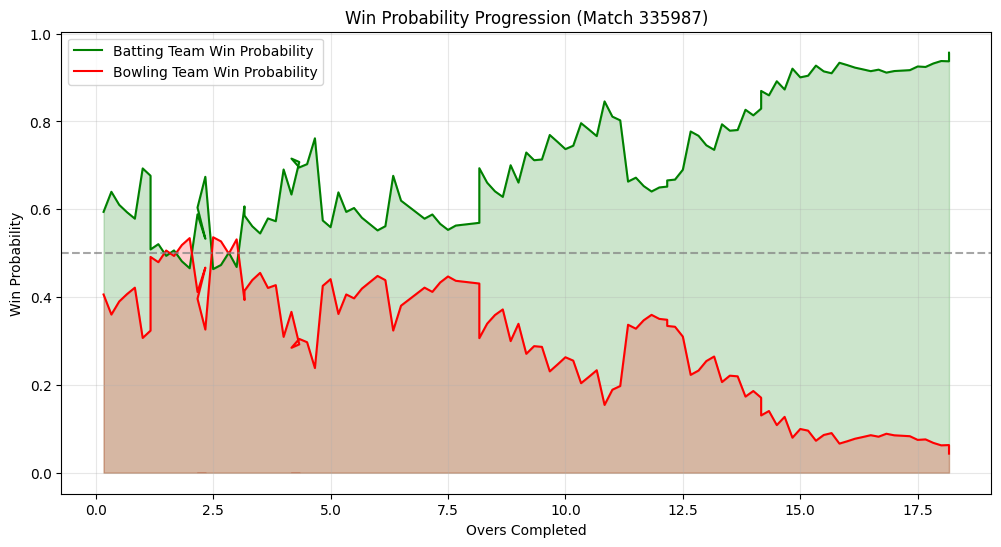

In [46]:
plt.figure(figsize=(12,6))

batting_prob = probs
bowling_prob = [1-p for p in probs]

plt.plot(overs, batting_prob, color='green', label='Batting Team Win Probability')
plt.plot(overs, bowling_prob, color='red', label='Bowling Team Win Probability')

# Fill areas 
plt.fill_between(overs, batting_prob, color='green', alpha=0.2)
plt.fill_between(overs, bowling_prob, color='red', alpha=0.2)

# 50% reference line
plt.axhline(0.5, linestyle='--', color='gray', alpha=0.7)

plt.xlabel("Overs Completed")
plt.ylabel("Win Probability")

plt.title(f"Win Probability Progression (Match {match_id})")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [39]:
#deliveries['match_id'].unique()[:10]

array([335982, 335983, 335984, 335985, 335986, 335987, 335988, 335989,
       335990, 335991])